In [35]:
import pandas as pd
import matplotlib.pyplot as plt

In [36]:
df = pd.read_csv("quran_memorization.csv")

print("First 5 rows:")
print(df.head())

First 5 rows:
   study_hours  revision_hours  sleep_hours  consistency  memorization
0            6               4            5            1             1
1            5               1            7            1             1
2            6               1            5            0             1
3            2               4            8            0             1
4            4               2            4            0             1


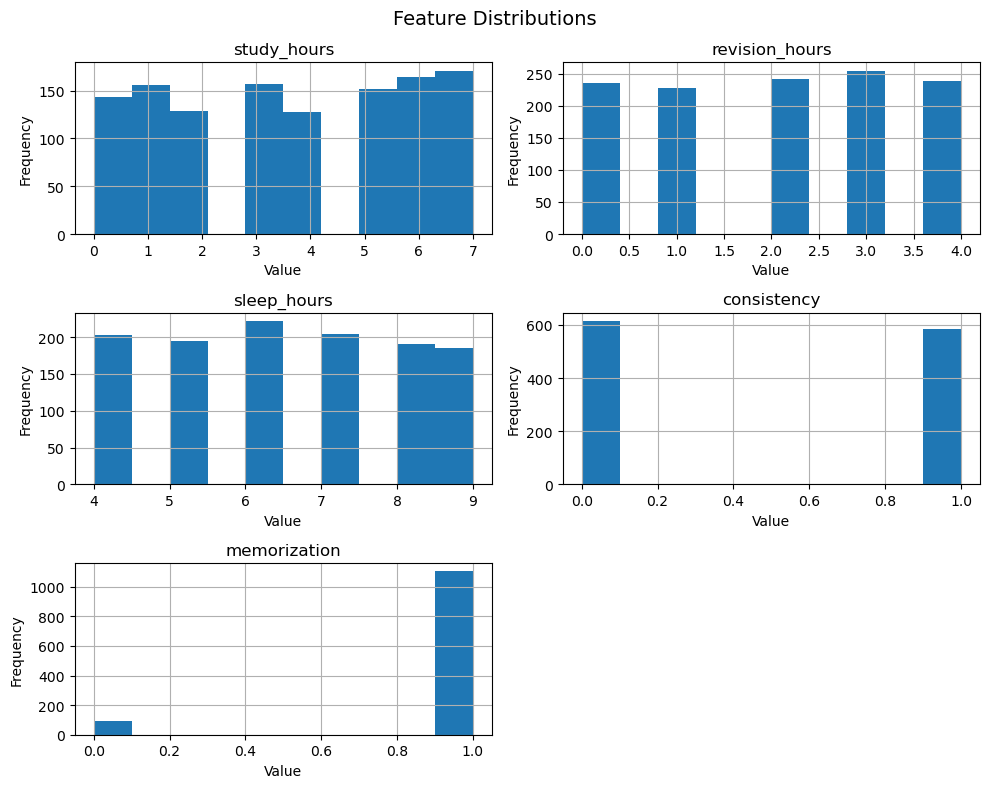

In [37]:
import matplotlib.pyplot as plt

df.hist(figsize=(10,8), bins=10)

plt.suptitle("Feature Distributions", fontsize=14)

for ax in plt.gcf().axes:
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [38]:
X = df[['study_hours', 'revision_hours', 'sleep_hours', 'consistency']]
y = df['memorization']

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [41]:
accuracy = model.score(X_test, y_test)
print("\nModel Accuracy:", accuracy)


Model Accuracy: 0.9958333333333333


In [42]:
print("\nModel Coefficients:")
print(model.coef_)


Model Coefficients:
[[2.70342852 2.87171737 0.04347034 4.75180035]]


In [44]:
study = float(input("Enter study hours: "))
revision = float(input("Enter revision hours: "))
sleep = float(input("Enter sleep hours: "))
consistency = int(input("Consistency (1=Yes, 0=No): "))

sample = pd.DataFrame([[study, revision, sleep, consistency]],
                      columns=['study_hours', 'revision_hours', 'sleep_hours', 'consistency'])

prediction = model.predict(sample)

if prediction[0] == 1:
    print("\n✅ Prediction: Good Memorization")
else:
    print("\n❌ Prediction: Weak Memorization")

Enter study hours:  0
Enter revision hours:  0
Enter sleep hours:  12
Consistency (1=Yes, 0=No):  1



❌ Prediction: Weak Memorization
